In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install numba

In [3]:
import matplotlib.pyplot as plt
import numba
from numba import cuda
import numpy as np
import time
import math

Image size: 718 x 718
Pixels count: 515524


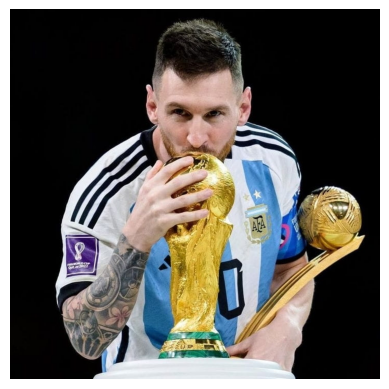

In [4]:
img = plt.imread('/content/drive/MyDrive/Dataset/HPC/wc.jpg')
h, w, _ = img.shape
pixelCount = h * w

print(f"Image size: {h} x {w}")
print(f"Pixels count: {pixelCount}")

plt.imshow(img)
plt.axis("off")
plt.show()

**Grayscale stretch**



Grayscale conversion (Map)

In [5]:
@cuda.jit
def rgb2gray_gpu_2d(rgb, grayscale):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  h, w, _ = rgb.shape
  if tidy < h and tidx < w:
    g = (int(rgb[tidy, tidx, 0]) + int(rgb[tidy, tidx, 1]) + int(rgb[tidy, tidx, 2])) // 3
    grayscale[tidy, tidx] = np.uint8(g)

Intensity of image (Reduce)

In [6]:
@cuda.jit
def min_gpu_1d(flatten_grayscale, dst_min):
  cache = cuda.shared.array(0, numba.int32)
  pixelCount = flatten_grayscale.shape[0]

  localtid = cuda.threadIdx.x
  tid = cuda.blockIdx.x * cuda.blockDim.x * 2 + cuda.threadIdx.x
  v = 255
  if tid < pixelCount:
    v = int(flatten_grayscale[tid])
  if tid + cuda.blockDim.x < pixelCount:
    v = min(v, int(flatten_grayscale[tid + cuda.blockDim.x]))
  cache[localtid] = v

  cuda.syncthreads()

  s = cuda.blockDim.x // 2
  while s > 0:
    if (localtid < s):
      cache[localtid] = min(cache[localtid], cache[localtid + s])
    cuda.syncthreads()
    s = s // 2

  if (localtid == 0):
    dst_min[cuda.blockIdx.x] = cache[0]


@cuda.jit
def max_gpu_1d(flatten_grayscale, dst_max):
  cache = cuda.shared.array(0, numba.int32)
  pixelCount = flatten_grayscale.shape[0]

  localtid = cuda.threadIdx.x
  tid = cuda.blockIdx.x * cuda.blockDim.x * 2 + cuda.threadIdx.x

  v = 0
  if tid < pixelCount:
    v = int(flatten_grayscale[tid])
  if tid + cuda.blockDim.x < pixelCount:
    v = max(v, int(flatten_grayscale[tid + cuda.blockDim.x]))
  cache[localtid] = v

  cuda.syncthreads()

  s = cuda.blockDim.x // 2
  while s > 0:
    if (localtid < s):
      cache[localtid] = max(cache[localtid], cache[localtid + s])
    cuda.syncthreads()
    s = s // 2

  if (localtid == 0):
    dst_max[cuda.blockIdx.x] = cache[0]


def reduce_gpu(flatten_grayscale, kernel, sharedSize):
  current = flatten_grayscale
  size = flatten_grayscale.shape[0]
  while size > 1:
    gridSize = math.ceil(size / (sharedSize * 2))
    output = cuda.device_array((gridSize, ), np.int32)
    kernel[gridSize, sharedSize, 0, sharedSize * 4](current, output)
    current = output
    size = gridSize
  return int(current.copy_to_host()[0])

Grayscale to graystretch

In [7]:
@cuda.jit
def rgb2graystretch_gpu_2d(grayscale, graystretch, gray_min, gray_max):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  h, w = grayscale.shape
  if tidx < w and tidy < h:
    if gray_max > gray_min:
      graystretch[tidy, tidx] = np.uint8((int(grayscale[tidy, tidx]) - gray_min) / (gray_max - gray_min) * 255)
    else:
      graystretch[tidy, tidx] = grayscale[tidy, tidx]

In [8]:
def graystretch_gpu(rgb, blockSize, sharedSize):
  h, w, _ = rgb.shape
  gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
  rgb_gpu = cuda.to_device(rgb)
  gray_gpu = cuda.device_array((h, w), np.uint8)
  stretched_gpu = cuda.device_array((h, w), np.uint8)

  rgb2gray_gpu_2d[gridSize, blockSize](rgb_gpu, gray_gpu)
  gray_flat = gray_gpu.reshape(h * w)
  g_min = reduce_gpu(gray_flat, min_gpu_1d, sharedSize)
  g_max = reduce_gpu(gray_flat, max_gpu_1d, sharedSize)
  rgb2graystretch_gpu_2d[gridSize, blockSize](gray_gpu, stretched_gpu, g_min, g_max)

  host_gray = gray_gpu.copy_to_host()
  host_stretched = stretched_gpu.copy_to_host()
  return host_gray, host_stretched, g_min, g_max

def gpu_time_stretch(img, blockSize, sharedSize, n_runs):
  graystretch_gpu(img, blockSize, sharedSize)

  times = []
  for i in range(n_runs):
      start = time.time()
      gray_img, stretched_img, g_min, g_max = graystretch_gpu(img, blockSize, sharedSize)
      times.append(time.time() - start)
      print(f"Run {i+1:2d}: {times[-1]:.4f}s")

  mean_t, std_t = np.mean(times), np.std(times)
  print(f"\nGPU grayscale stretch (min={g_min}, max={g_max}) with 2D block size = {blockSize}, sharedSize = {sharedSize}: {mean_t:.4f}s ± {std_t:.4f}s (mean of {n_runs} runs)")

  return gray_img, stretched_img, g_min, g_max

/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Run  1: 0.0046s
Run  2: 0.0043s
Run  3: 0.0040s
Run  4: 0.0039s
Run  5: 0.0051s
Run  6: 0.0150s
Run  7: 0.0095s
Run  8: 0.0047s
Run  9: 0.0115s
Run 10: 0.0099s

GPU grayscale stretch (min=0, max=255) with 2D block size = (32, 32), sharedSize = 256: 0.0072s ± 0.0037s (mean of 10 runs)


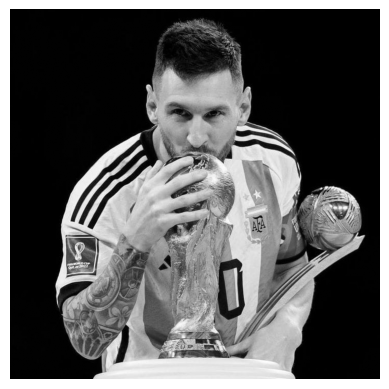

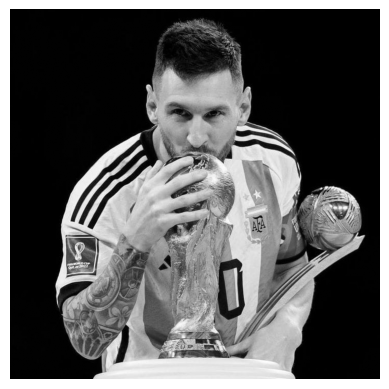

In [9]:
blockSize = (32, 32)
sharedSize = 256
N_RUNS = 10

grayscale_img, graystretch_img, g_min, g_max = gpu_time_stretch(img, blockSize, sharedSize, N_RUNS)

plt.imshow(grayscale_img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.savefig("grayscale_gpu_2D.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

plt.imshow(graystretch_img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.savefig("graystretch_gpu_2D.jpg", bbox_inches="tight", pad_inches=0)
plt.show()